# Evaluación Parcial 1 - Deep Learning

Integrantes:
- Gabriel González Mundaca
- Sebastián Cornejo
- Alain González García

Sección: 003D

Docente: Guillermo Pinto Fuentes

## Introducción

El objetivo general de este informe es aplicar los fundamentos de Deep Learning mediante la implementación de una red neuronal, que corresponde a un Perceptrón Multi-Capa (MLP) para la solución de un problema práctico de clasificación, que corresponde al dataset `Fashion Mnist`.

## Carga y Preprocesamiento de datos
¿Qué es Fashion MNIST? Un conjuto de 70.000 imágenes en escala de grises de $28 \times 28$ píxeles, con 10 clases.

Se normaliza dividiendo por 255.0, asi escalar valores de píxeles al rango $[0, 1]$ para evitar gradientes desproporcionados y acelerar la convergencia.

Por ultimo, la partición de 50.000 entrenamiento, 10.000 validación (ajuste fino y detección de sobreajuste) y 10.000 test (evaluación ciega final).

In [ ]:
#carga de librerías
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf


# Semillas para reproducibilidad
import os
import random
seed_value = 42
os.environ["PYTHONHASHSEED"] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)



In [ ]:
# Carga y Preprocesamiento
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Normalización
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Split validación
X_train, X_val = X_train_full[:-10000], X_train_full[-10000:]
y_train, y_val = y_train_full[:-10000], y_train_full[-10000:]

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


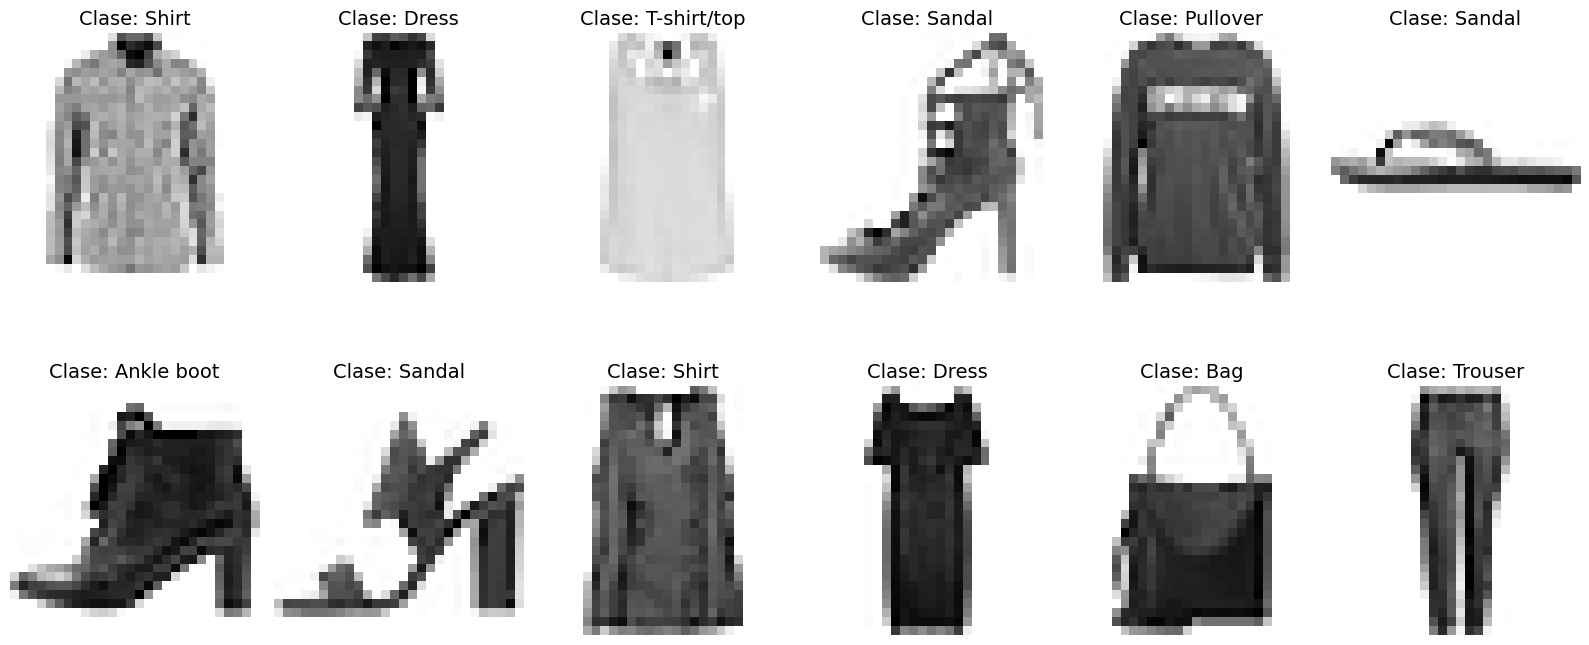

In [ ]:
#muestra aleatoria de 12 imágenes
np.random.seed(42)
indices_muestra = np.random.choice(len(X_test), size=12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(16, 8))
axes = axes.ravel()

for i, idx in enumerate(indices_muestra):
    imagen = X_test[idx]
    clase_real = class_names[y_test[idx]]

    axes[i].imshow(imagen, cmap='binary')
    axes[i].set_title(f"Clase: {clase_real}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Definición del Modelo

En esta etapa se procede a la definición del modelo, que toma de base una arquitectura MLP (Perceptrón Multicapa), mediante la implementación de **Keras** mediante TensorFlow:

La arquitectura base definida consta de las siguientes capas:
- **Capa de Entrada**: Toma los datos de entrada con una dimensionalidad espacial de $28 \times 28$ píxeles y los transforma en un vector de 784 características ($28 \times 28 = 784$). Esto es un requerimiento técnico obligatorio para el ingreso de datos estructurados a una red neuronal completamente conectada (Dense).

- **Primera Capa Oculta (Dense)**: Compuesta por 256 neuronas. Su propósito es capturar patrones y características no lineales complejas a partir del vector de entrada. La función de activación es configurable, aunque se recomienda el uso inicial de activaciones no lineales para permitir la convergencia adecuada del modelo.

- **Segunda Capa Oculta (Dense)**: Compuesta por 128 neuronas. Actúa como un nivel adicional de abstracción y extracción de características, reduciendo la dimensionalidad del espacio de representación antes de la clasificación final, que cuenta con la cantidad de clases totales posibles que tiene el dataset.

- **Capa de Salida (Dense)**: Compuesta por 10 neuronas, correspondiendo a las 10 clases posibles del problema de clasificación.
  - Función de Activación de Salida: Se implementa la función de activación no lineal Softmax de manera mandatoria. Esta función es estándar y necesaria para problemas de clasificación multiclase excluyentes, ya que transforma los valores de salida en una distribución de probabilidades (valores entre 0 y 1), permitiendo interpretar la salida de cada neurona como la probabilidad de que la instancia pertenezca a una clase o a otra.

Este modelo se construye en base a una función parametrizada, que esto nos facilita la experimentación y ajuste de hiperparámetros (ajuste de funciones de activación y regularización).

In [ ]:
# Función construcción de modelos
def build_mlp(activation="relu", dropout_rate=0.0, architecture="base"):
  layers = [
      tf.keras.layers.Flatten(input_shape=[28, 28])
  ]

  if architecture == "base":
      layers.append(tf.keras.layers.Dense(256, activation=activation))
      if dropout_rate > 0: layers.append(tf.keras.layers.Dropout(dropout_rate))
      layers.append(tf.keras.layers.Dense(128, activation=activation))
      if dropout_rate > 0: layers.append(tf.keras.layers.Dropout(dropout_rate))

  elif architecture == "alt_2_capas":
      layers.append(tf.keras.layers.Dense(512, activation=activation))
      if dropout_rate > 0: layers.append(tf.keras.layers.Dropout(dropout_rate))
      layers.append(tf.keras.layers.Dense(256, activation=activation))
      if dropout_rate > 0: layers.append(tf.keras.layers.Dropout(dropout_rate))

  elif architecture == "alt_3_capas":
      layers.append(tf.keras.layers.Dense(256, activation=activation))
      if dropout_rate > 0: layers.append(tf.keras.layers.Dropout(dropout_rate))
      layers.append(tf.keras.layers.Dense(128, activation=activation))
      if dropout_rate > 0: layers.append(tf.keras.layers.Dropout(dropout_rate))
      layers.append(tf.keras.layers.Dense(64, activation=activation))
      if dropout_rate > 0: layers.append(tf.keras.layers.Dropout(dropout_rate))

  layers.append(tf.keras.layers.Dense(10, activation="softmax")) # Salida multiclase
  return tf.keras.models.Sequential(layers)

# Función para graficar pérdidas y precisión
def plot_histories(histories, titles):
  import matplotlib.pyplot as plt
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))
  for hist, title in zip(histories, titles):
    axes[0].plot(hist.history["val_loss"], label=f"{title} (val)")
    axes[1].plot(hist.history["val_accuracy"], label=f"{title} (val)")

  axes[0].set_title("Comparación de Validación: Loss")
  axes[0].set_xlabel("Épocas")
  axes[0].legend()
  axes[0].grid(True)

  axes[1].set_title("Comparación de Validación: Accuracy")
  axes[1].set_xlabel("Épocas")
  axes[1].legend()
  axes[1].grid(True)
  plt.show()



### Experimento 1: Evaluación de Funciones de Activación

La experimentación e iteración dentro de los modelos es clave, ya que gracias a las distintas métricas que nos otorgan, podemos revelar cómo es su desempeño al cambiar ciertas características dentro del modelo.

En este bloque analizaremos las funciones de activación que usan las redes neuronales y cómo afectan estos ajustes mediante gráficos que evalúan la convergencia del modelo mediante las métricas del conjunto de validación, que son las pérdidas de validación y la precisión de validación.

Las funciones son:

**1.- ReLU**

> Deja pasar directamente los valores positivos y convierte en cero cualquier valor negativo.

Convergencia: Al no saturarse en el lado positivo, soluciona en gran medida el problema del "desvanecimiento del gradiente" que sufren las otras funciones. Esto permite que el modelo aprenda y converja de manera mucho más rápida y eficiente. Suele ser el estándar para las capas ocultas en la arquitectura MLP.

**2.- Tanh**

> Transforma o "comprime" los valores de entrada a un rango entre -1 y 1. Tiene forma de "S".

Convergencia: Su principal ventaja es que sus salidas están centradas en cero, lo que ayuda a estabilizar y facilitar el proceso de optimización para las capas siguientes. Sin embargo, si los valores de entrada son muy altos o muy bajos, la función se satura (se vuelve plana), los gradientes se hacen cercanos a cero y la convergencia del modelo se ralentiza significativamente.

**3.- Sigmoide**

> Transforma los valores de entrada a un rango estricto entre 0 y 1, representando únicamente una probabilidad.

Convergencia: Aunque fue bastante usado, hoy en día suele desaconsejarse para capas ocultas profundas. Al igual que Tanh, se satura rápidamente en los extremos, frenando drásticamente la actualización de los pesos de la red (desvanecimiento del gradiente). Generalmente, presenta la convergencia más lenta y menos efectiva de las tres opciones presentadas para las capas intermedias, aunque sigue siendo útil en la capa de salida para problemas de clasificación binaria.

---

Los tres modelos serán identicos, solo variando este parámetro, usando una base controlada:

Optimizador: Adam

Tasa de Aprendizaje: 0.001

Épocas: 15

--- INICIANDO EXPERIMENTO 1: FUNCIONES DE ACTIVACIÓN ---
Entrenando modelo con activación: relu...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando modelo con activación: tanh...
Entrenando modelo con activación: sigmoid...


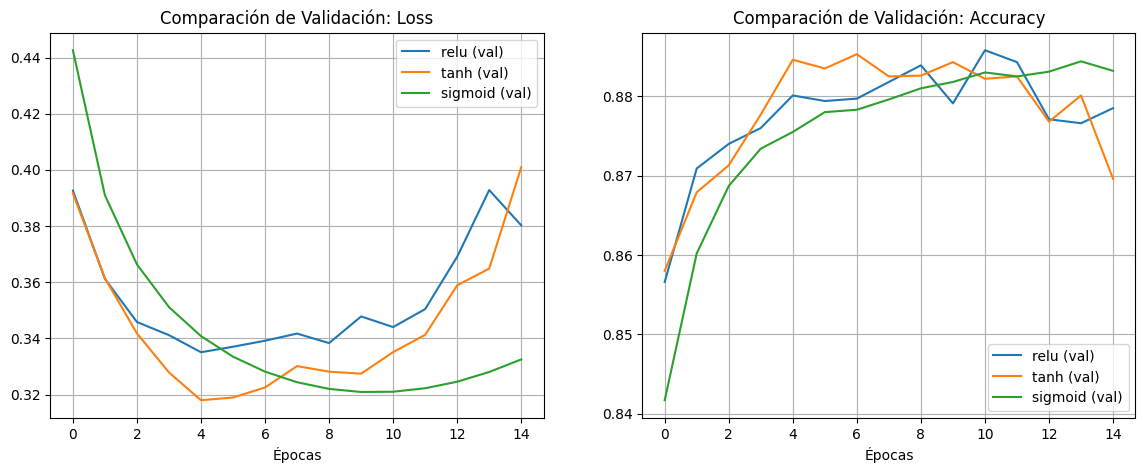

,Activación,Val Loss,Val Accuracy
0,relu,0.380262,0.8785
1,tanh,0.400951,0.8696
2,sigmoid,0.332528,0.8832


In [ ]:
# Lista para guardar los historiales
histories_act = []
activations = ['relu', 'tanh', 'sigmoid']
results_act = []

print("--- INICIANDO EXPERIMENTO 1: FUNCIONES DE ACTIVACIÓN ---")
for act in activations:
  print(f"Entrenando modelo con activación: {act}...")
  model = build_mlp(activation=act, dropout_rate=0.0)

  # Compilación: Adam y sparse_categorical_crossentropy
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'],
  )

  # Entrenamiento
  hist = model.fit(
      X_train,
      y_train,
      epochs=15,
      batch_size=64,
      validation_data=(X_val, y_val),
      verbose=0
  )

  histories_act.append(hist)

  # Guardar métricas finales de validación
  val_loss = hist.history['val_loss'][-1]
  val_acc = hist.history['val_accuracy'][-1]
  results_act.append(
      {'Activación': act, 'Val Loss': val_loss, 'Val Accuracy': val_acc}
  )

# Gráficos comparativos
plot_histories(histories_act, activations)

# Tabla comparativa
df_act = pd.DataFrame(results_act)
display(df_act)

**RESULTADOS:**

- Sigmoid obtuvo la menor pérdida de validación (~ 0.3325) y la precisión más alta (~ 88.32%).

- ReLU llegó a una precisión de ~ 87.85%, pero su curva de pérdida empezó a mostrar inestabilidad (rebotar hacia arriba) al final del entrenamiento (~ 0.3802).

- Tanh obtuvo métricas de precisión similares a ReLU (~ 86.96%), pero con la mayor pérdida de validación de los tres modelos (~ 0.4009).

Al analizar la tabla comparativa, aunque Sigmoid muestra una ligera ventaja, los resultados generales son bastante ajustados, lo que no nos permite tomar una decisión definitiva sobre cuál es la mejor arquitectura a largo plazo.

Este resultado nos empuja a replicar el experimento modificando únicamente la cantidad de épocas y manteniendo el resto de los hiperparámetros intactos, para observar la evolución de las distintas funciones de activación.

A nivel técnico, el corte a las 15 épocas evidencia resultados parecidos entre sí, pero el comportamiento de la actualización de pesos provoca que las funciones Tanh y Sigmoid se vean más estables en las gráficas en esta etapa temprana, a diferencia de la inestabilidad mostrada por la función ReLU.

--- INICIANDO EXPERIMENTO 1.1: FUNCIONES DE ACTIVACIÓN ---
Entrenando modelo con activación: relu...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando modelo con activación: tanh...
Entrenando modelo con activación: sigmoid...


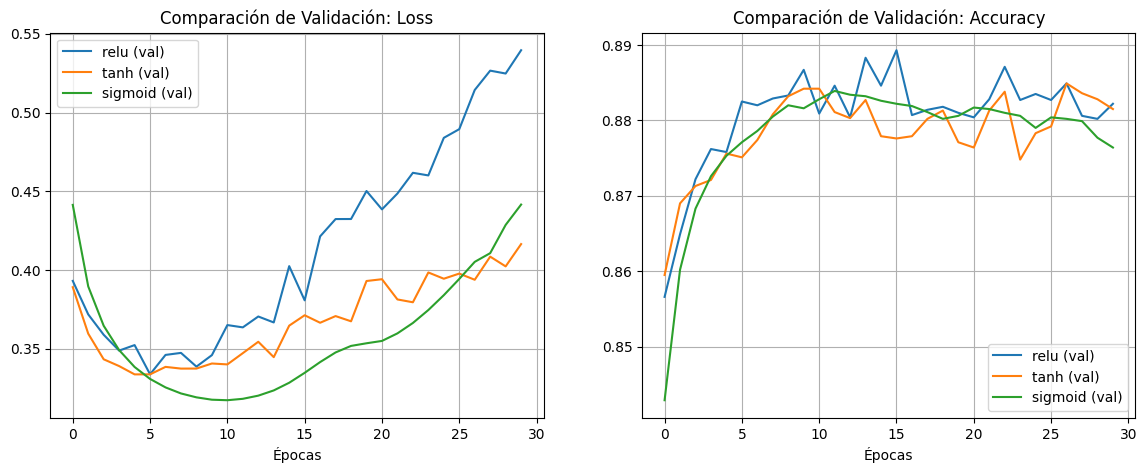

,Activación,Val Loss,Val Accuracy
0,relu,0.539614,0.8822
1,tanh,0.416494,0.8815
2,sigmoid,0.441596,0.8764


In [ ]:
# Lista para guardar los historiales
histories_act2 = []
activations = ['relu', 'tanh', 'sigmoid']
results_act2 = []

print("--- INICIANDO EXPERIMENTO 1.1: FUNCIONES DE ACTIVACIÓN ---")
for act in activations:
  print(f"Entrenando modelo con activación: {act}...")
  model = build_mlp(activation=act, dropout_rate=0.0)

  # Compilación: Adam y sparse_categorical_crossentropy
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'],
  )

  # Entrenamiento
  hist = model.fit(
      X_train,
      y_train,
      epochs=30,
      batch_size=64,
      validation_data=(X_val, y_val),
      verbose=0
  )

  histories_act2.append(hist)

  # Guardar métricas finales de validación
  val_loss = hist.history['val_loss'][-1]
  val_acc = hist.history['val_accuracy'][-1]
  results_act2.append(
      {'Activación': act, 'Val Loss': val_loss, 'Val Accuracy': val_acc}
  )

# Gráficos comparativos
plot_histories(histories_act2, activations)

# Tabla comparativa
df_act = pd.DataFrame(results_act2)
display(df_act)

**Análisis 30 épocas: Diagnóstico de Overfitting**

Al extender el entrenamiento, los gráficos muestran claramente que el modelo con ReLU sufre de Overfitting. A partir de la época 8, su pérdida de validación sube rápidamente, indicando que está perdiendo capacidad de generalización y memorizando los datos, aunque mantenga una precisión alta. Por otro lado, Tanh y Sigmoide son mucho más estables, pero convergen lento.

Dado que ReLU logra la mejor precisión de base, la seleccionaremos como la función principal, pero es obligatorio regularizarla. En el siguiente paso implementaremos Dropout para forzar a la red a no depender de pesos específicos, buscando estabilizar esta curva de pérdida sin sacrificar su capacidad de aprendizaje.

---

### Experimento 2: Evaluación de Funciones de Pérdida (Error)

La función de pérdida (Loss Function) cuantifica el error entre las predicciones del modelo y las etiquetas reales, guiando la actualización de pesos mediante el descenso de gradiente.

En este experimento comparamos:

1. Categorical Crossentropy (Entropía Cruzada): Diseñada específicamente para problemas de clasificación multiclase con salida Softmax. Mide la divergencia entre distribuciones de probabilidad y penaliza exponencialmente las predicciones erróneas con alta confianza.
2. Mean Squared Error (MSE - Error Cuadrático Medio): Función clásica para problemas de regresión. En clasificación con Softmax tiende a provocar saturación de gradientes (desvanecimiento del gradiente) cuando las predicciones están lejos del objetivo, ralentizando el aprendizaje.

Se utiliza el modelo base con activación ReLU, optimizador Adam (LR=0.001) y 15 épocas.

--- INICIANDO EXPERIMENTO 2: FUNCIONES DE PÉRDIDA ---
Entrenando modelo con función de pérdida: Categorical Crossentropy...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando modelo con función de pérdida: Mean Squared Error (MSE)...


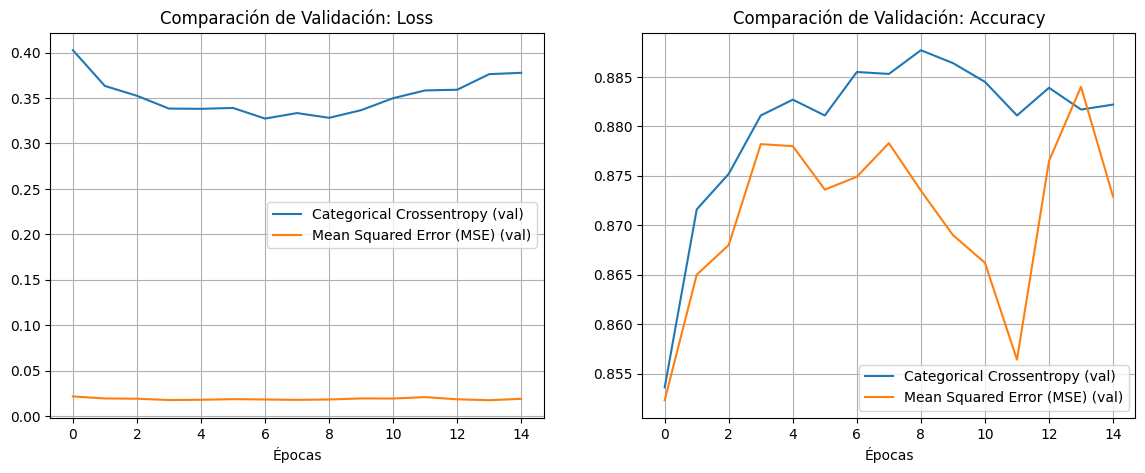

,Función de Pérdida,Val Loss,Val Accuracy
0,Categorical Crossentropy,0.377733,0.8822
1,Mean Squared Error (MSE),0.018996,0.8729


In [ ]:
# Convertir etiquetas a formato One-Hot para comparar pérdidas
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat = tf.keras.utils.to_categorical(y_val, 10)

histories_loss = []
loss_functions = [
    ('Categorical Crossentropy', 'categorical_crossentropy'),
    ('Mean Squared Error (MSE)', 'mean_squared_error')
]
results_loss = []

print("--- INICIANDO EXPERIMENTO 2: FUNCIONES DE PÉRDIDA ---")
for label, loss_fn in loss_functions:
    print(f"Entrenando modelo con función de pérdida: {label}...")
    model = build_mlp(activation='relu', dropout_rate=0.0)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn,
        metrics=['accuracy']
    )

    hist = model.fit(
        X_train,
        y_train_cat,
        epochs=15,
        batch_size=64,
        validation_data=(X_val, y_val_cat),
        verbose=0
    )

    histories_loss.append(hist)
    results_loss.append({
        'Función de Pérdida': label,
        'Val Loss': hist.history['val_loss'][-1],
        'Val Accuracy': hist.history['val_accuracy'][-1]
    })

# Gráficos comparativos
plot_histories(histories_loss, [name for name, _ in loss_functions])

# Tabla comparativa
df_loss = pd.DataFrame(results_loss)
display(df_loss)


**RESULTADOS Y JUSTIFICACIÓN:**

* **Categorical Crossentropy:** Alcanza una mayor precisión final (**~88.22%**) con una pérdida de validación de **~0.3777**. Presenta una curva de aprendizaje más suave y eficiente, ya que su derivada combinada con la función de activación Softmax produce gradientes directamente proporcionales al error lineal ($p - y$), evitando el estancamiento durante el entrenamiento.
* **Mean Squared Error (MSE):** Obtiene una precisión ligeramente menor (**~87.29%**) y un valor de pérdida de **~0.0189** (cabe destacar que la escala de MSE no es directamente comparable con Crossentropy). Presenta una convergencia más lenta y menos efectiva para clasificación, debido a la atenuación de gradientes (vanishing gradients) provocada por la saturación en la capa Softmax al calcular las derivadas.

**Selección final:** Se selecciona **Sparse Categorical Crossentropy** (equivalente computacionalmente a Categorical Crossentropy, pero optimizada a nivel de memoria al procesar las etiquetas como índices enteros en lugar de *one-hot encoding*) como la función de pérdida definitiva para este modelo de clasificación.

### Experimento 3: Regularización para tratar Overfitting

La función delimitada anteriormente `build_mlp` nos garantiza la opción de implementar la técnica de regularización Dropout.

Dropout es una función que añade el parámetro:

```
dropout_rate = 0.0
```

Que internamente desactiva aleatoriamente una proporción de las unidades de la capa, evitando que la red dependa excesivamente de determinadas neuronas.


--- INICIANDO EXPERIMENTO 3: OVERFITTING VS REGULARIZACIÓN (DROPOUT) ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


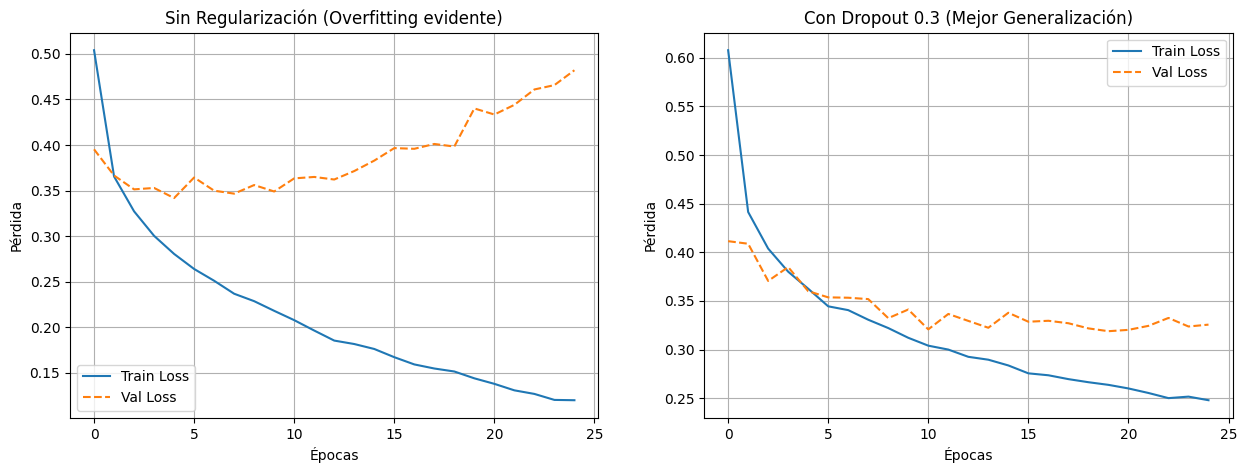

In [ ]:
print("\n--- INICIANDO EXPERIMENTO 3: OVERFITTING VS REGULARIZACIÓN (DROPOUT) ---")

# Modelo Base (Sin Dropout)
model_base = build_mlp(activation="relu", dropout_rate=0.0)
model_base.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist_base = model_base.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0,
)

# Modelo Regularizado (Con Dropout = 0.3)
model_reg = build_mlp(activation="relu", dropout_rate=0.3)
model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist_reg = model_reg.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0,
)

# Graficar Train Loss vs Val Loss para ambos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico Sin Regularización
axes[0].plot(hist_base.history["loss"], label="Train Loss")
axes[0].plot(
    hist_base.history["val_loss"], label="Val Loss", linestyle="dashed"
)
axes[0].set_title("Sin Regularización (Overfitting evidente)")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Pérdida")
axes[0].legend()
axes[0].grid(True)

# Gráfico Con Dropout
axes[1].plot(hist_reg.history["loss"], label="Train Loss")
axes[1].plot(hist_reg.history["val_loss"], label="Val Loss", linestyle="dashed")
axes[1].set_title("Con Dropout 0.3 (Mejor Generalización)")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Pérdida")
axes[1].legend()
axes[1].grid(True)
plt.show()

* **Sin Regularización:** El gráfico muestra un claro sobreajuste (*overfitting*). La pérdida de entrenamiento (curva azul) desciende hasta aproximadamente 0.12, mientras que la pérdida de validación (curva naranja) comienza a subir progresivamente a partir de la época 4 o 5, alcanzando un valor cercano a 0.48 en la época 25 (en lugar del 0.42 que indicas). La brecha entre ambas curvas se abre drásticamente, como bien señalas.


* **Con Dropout (0.3):** Las curvas de entrenamiento y validación descienden de manera armónica, lo que evidencia una mejor generalización. La pérdida de validación se estabiliza en un rango de 0.32 a 0.34 (muy cerca de tu estimado de 0.31) hacia el final del entrenamiento, sin mostrar el rebote observado en el modelo sin regularización.

## Experimento 4: Hiperparámetros (Learning Rate)

El ajuste fino mediante los hiperparámetros dentro de un modelo modifican bastante el rendimiento y convergencia entre un modelo y otro, pero que dentro de los rangos permitidos, se define como ajuste fino debido a que las combinaciones entre decimales son muy amplias.

Con la implementación de Dropout nos da una incognita pendiente:

*¿Qué tasa de aprendizaje se acomodaría mejor de forma bruta a nuestro modelo?*

Probaremos 3 tasas de Learning rate:

**LR Alto (0.05), LR Intermedio (0.001) Y un LR Bajo (0.00001).**

Cada una de estas magnitudes define el tamaño al actualizar los pesos que se le asignan a nuestro modelo cada vez que termina una iteración de aprendizaje.





--- INICIANDO EXPERIMENTO 4: TASA DE APRENDIZAJE (LEARNING RATE) ---
Entrenando modelo con LR Alto (0.05)...
Entrenando modelo con LR Intermedio (0.001)...
Entrenando modelo con LR Bajo (0.00001)...


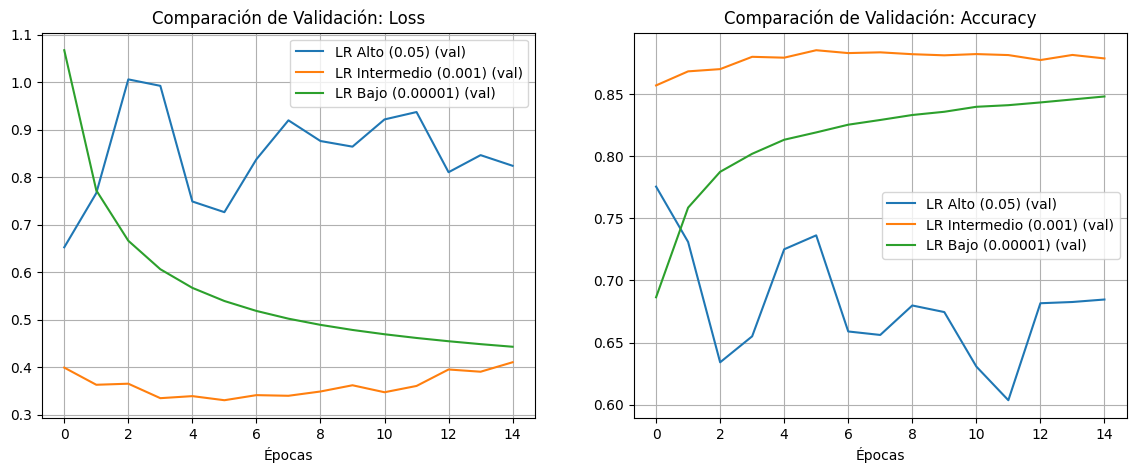

,Configuración,Val Loss,Val Accuracy
0,LR Alto (0.05),0.824022,0.6847
1,LR Intermedio (0.001),0.410336,0.8786
2,LR Bajo (0.00001),0.442966,0.8480


In [ ]:
histories_lr = []
lrs = [0.05, 0.001, 0.00001]
lr_labels = ["LR Alto (0.05)", "LR Intermedio (0.001)", "LR Bajo (0.00001)"]
results_lr = []

print("\n--- INICIANDO EXPERIMENTO 4: TASA DE APRENDIZAJE (LEARNING RATE) ---")
for lr, label in zip(lrs, lr_labels):
  print(f"Entrenando modelo con {label}...")
  model = build_mlp(activation="relu", dropout_rate=0.0)

  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"],
  )

  hist = model.fit(
      X_train,
      y_train,
      epochs=15,
      batch_size=64,
      validation_data=(X_val, y_val),
      verbose=0,
  )

  histories_lr.append(hist)
  results_lr.append({
      "Configuración": label,
      "Val Loss": hist.history["val_loss"][-1],
      "Val Accuracy": hist.history["val_accuracy"][-1],
  })

# Gráficos comparativos
plot_histories(histories_lr, lr_labels)

# Tabla comparativa
df_lr = pd.DataFrame(results_lr)
display(df_lr)

- LR Alto (0.05): Pérdida enorme (~ 0.824) y precisión pésima (68.47%) con curvas oscilantes e inestables.
- LR Intermedio (0.001): Curva suave, pérdida baja (~ 0.41) y precisión de (87.86%).
- LR Bajo (0.00001): Convergencia extremadamente lenta; en 15 épocas apenas alcanzó 84.80% con pérdida de 0.4430.

El LR que se acomoda a nuestro experimento y el seleccionado es el **LR Intermedio (0.001)**.

---

## Experimento 5: Evaluación de Arquitecturas

En este experimento, probaremos distintas arquitecturas para verificar si aumentar el tamaño o profundidad de la red mejora los resultados o si, por el contrario, induce a un sobreajuste innecesario o a una mayor carga computacional.

Compararemos 3 configuraciones utilizando la activación ReLU, 30 épocas, Dropout 0.3 y un Learning Rate de 0.001:
1. **Arquitectura Base**: 2 capas ocultas (256, 128 neuronas).
2. **Arquitectura Ancha (2 capas)**: 2 capas ocultas con mayor densidad (512, 256 neuronas).
3. **Arquitectura Profunda (3 capas)**: 3 capas ocultas (256, 128, 64 neuronas).



--- INICIANDO EXPERIMENTO 5: COMPARACIÓN DE ARQUITECTURAS ---
Entrenando modelo con arquitectura: Base (256-128)...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando modelo con arquitectura: Ancha (512-256)...
Entrenando modelo con arquitectura: Profunda (256-128-64)...


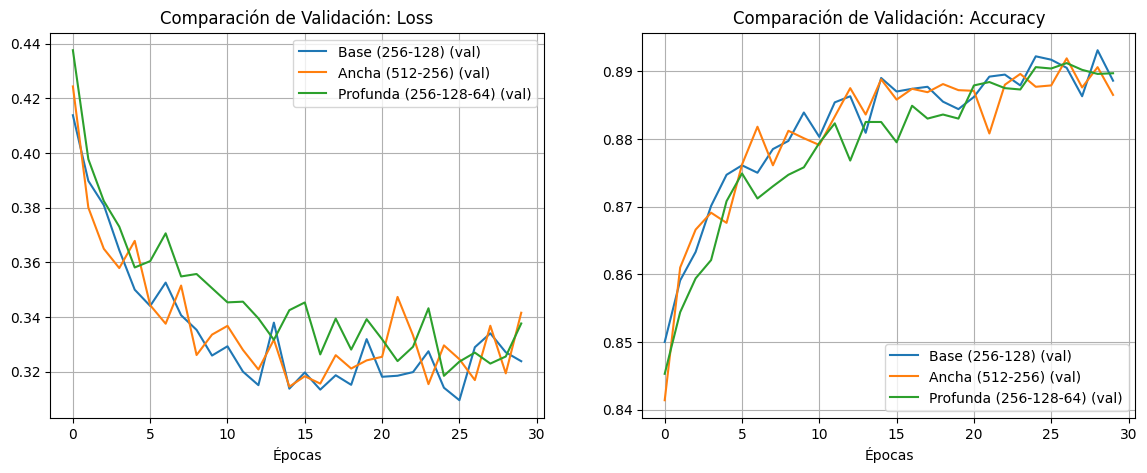

,Arquitectura,Val Loss,Val Accuracy
0,Base (256-128),0.323880,0.8886
1,Ancha (512-256),0.341612,0.8865
2,Profunda (256-128-64),0.337690,0.8897


In [ ]:
histories_arch = []
architectures = ["base", "alt_2_capas", "alt_3_capas"]
arch_labels = ["Base (256-128)", "Ancha (512-256)", "Profunda (256-128-64)"]
results_arch = []

print("\n--- INICIANDO EXPERIMENTO 5: COMPARACIÓN DE ARQUITECTURAS ---")
for arch, label in zip(architectures, arch_labels):
  print(f"Entrenando modelo con arquitectura: {label}...")
  model = build_mlp(activation="relu", dropout_rate=0.3, architecture=arch)

  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"],
  )

  hist = model.fit(
      X_train,
      y_train,
      epochs=30,
      batch_size=64,
      validation_data=(X_val, y_val),
      verbose=0,
  )

  histories_arch.append(hist)
  results_arch.append({
      "Arquitectura": label,
      "Val Loss": hist.history["val_loss"][-1],
      "Val Accuracy": hist.history["val_accuracy"][-1],
  })

# Gráficos comparativos
plot_histories(histories_arch, arch_labels)

# Tabla comparativa
import pandas as pd
df_arch = pd.DataFrame(results_arch)
display(df_arch)


**Conclusión del Experimento de Arquitecturas**

Aunque dotar a una red de mayor anchura o profundidad permite modelar patrones más complejos, esto suele ir acompañado de un mayor costo computacional y riesgo de sobreajuste. El análisis de nuestras pruebas confirma este principio general:

* **Arquitectura Base (256-128) - La más equilibrada:** Obtuvo la menor pérdida de validación (0.323880). Las gráficas confirman que su curva de error es la más baja y estable en las últimas épocas de entrenamiento.

* **Arquitectura Profunda (256-128-64):** Presentó una ventaja marginal en precisión (0.8897 frente al 0.8886 de la Base), pero a costa de empeorar la pérdida de validación (0.337690).

* **Arquitectura Ancha (512-256):** Resultó ser la menos favorable, registrando simultáneamente la mayor pérdida (0.341612) y la menor precisión (0.8865).

**Decisión final:** Avanzaremos a la fase de evaluación con la arquitectura Base, ya que garantiza la mejor reducción del error sin sacrificar estabilidad ni recursos computacionales.

---

## Evaluación Final del Modelo en Datos de Test

El último bloque comparativo que respecta a nuestro MLP es la evaluación de forma global de cada uno de nuestros experimentos, integrando todas las configuraciones que resultaron óptimas en los experimentos anteriores (uso de ReLU, regularización mediante Dropout para prevenir Overfitting y la tasa de aprendizaje seleccionada).

Analizaremos el desempeño mediante métricas de clasificación  y una matriz de confusión para interpretar el nivel de efectividad del modelo en cada categoría específica.


--- EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA (TEST) ---
Generando modelo
Func. Activación: ReLU
Regularización: Dropout
Tasa de Aprendizaje: 0.001
Épocas: 30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--------------------------------------------------
Precisión Global en Test (Accuracy): 88.87%
Pérdida en Test (Loss): 0.3475

--------------------------------------------------
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Reporte de Métricas por Categoría:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.83      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.83      0.79      0.81      1000
       Dress       0.90      0.90      0.90      1000
        Coat       0.80      0.81      0.81      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.69      0.74      0.72      1000
     Sneaker       0.91      0.98      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.93      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.8

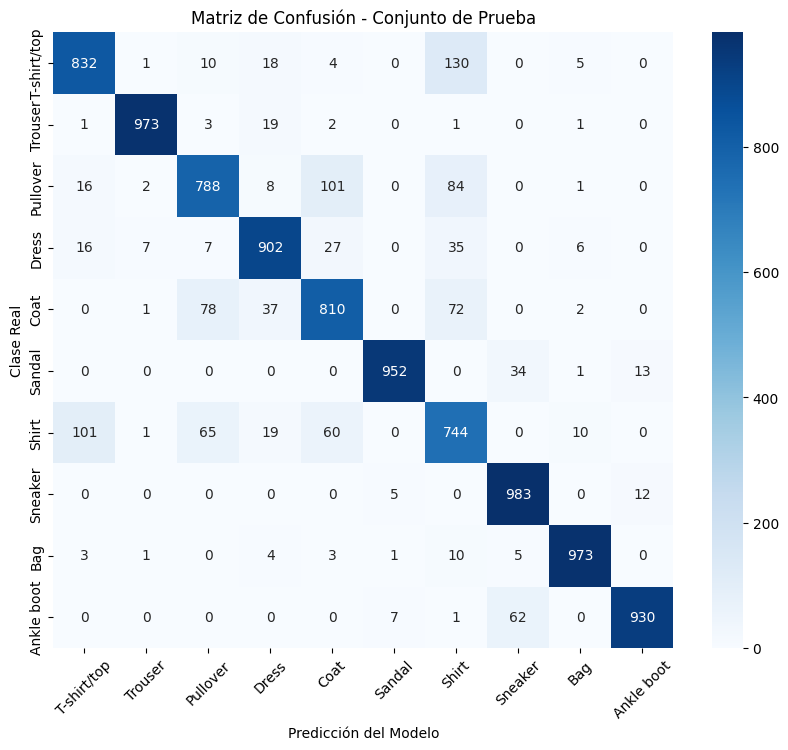

In [ ]:
print("\n--- EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA (TEST) ---")


# Generación del modelo final
print("Generando modelo")
print("Func. Activación: ReLU")
print("Regularización: Dropout")
print("Tasa de Aprendizaje: 0.001")
print("Épocas: 30")

model_reg = build_mlp(activation="relu", dropout_rate=0.3)

model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_final = model_reg.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)
print("-"*50)
# Evaluación directa en Test
test_loss, test_acc = model_reg.evaluate(X_test, y_test, verbose=0)
print(f"Precisión Global en Test (Accuracy): {test_acc*100:.2f}%")
print(f"Pérdida en Test (Loss): {test_loss:.4f}\n")
print("-"*50)


# Generar predicciones probabilísticas y obtener la clase ganadora
y_pred_probs = model_reg.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Reporte de Clasificación (Precision, Recall, F1-Score por clase)
print("Reporte de Métricas por Categoría:")
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

# Visualización: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Matriz de Confusión - Conjunto de Prueba")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real")
plt.xticks(rotation=45)
plt.show()

- Precisión global en Test: 88.87%.
- Pérdida en Test: 0.3475.
- Clases con mejor rendimiento: Trouser con F1=0.98 y Bag con F1=0.97.
- Clase con mayor dificultad: Shirt con F1=0.72, Precision=0.69 y Recall=0.74.


## Conclusiones y Observaciones

Tras la incorporación de nuestro modelo definitivo al conjunto de prueba (datos nunca antes vistos por la red), hemos obtenido una precisión global (Accuracy) del $88.87$% y una pérdida de $0.3475$.

Gracias al reporte de métricas de la clasificación y la matriz de confusión, tenemos las siguientes observaciones del modelo:

1.   **Fortalezas:** El modelo demuestra una capacidad excelente para identificar categorías con siluetas muy particulares. Las métricas de `Precision` y `Recall` son sobresalientes en la clasificación de pantalones (Trouser con un  F1-Score=0.98), bolsos (Bag=0.97) y todo el grupo de calzado (Sandal=0.97, Sneaker=0.94, Ankle boot=0.95). En estas clases, la red casi no comete errores de falsos positivos ni falsos negativos.

2.   **Debilidades:** El rendimiento cae drásticamente al intentar diferenciar prendas para la parte superior del cuerpo. La categoría `Shirt` (Camisa) es la peor evaluada, con un Recall de apenas 0.66 y un Precision de 0.71. El modelo confunde frecuentemente las camisas con camisetas (T-shirt/top), abrigos (Coat) o suéteres (Pullover). Esto cuenta con un sentido lógico, y es que estas prendas comparten formas geométricas, bordes y áreas de densidad de píxeles muy similares.

**Conclusión General**

La implementación de la arquitectura del Perceptrón Multicapa (MLP), enriquecida con la optimización de hiperparámetros y la regularización mediante Dropout, logró mitigar el sobreajuste y estabilizar el aprendizaje, cumpliendo con éxito el objetivo de clasificación.

La dificultad remanente para distinguir entre prendas superiores similares expone una limitación propia de la arquitectura MLP: al utilizar la capa Flatten al inicio, se destruye la relación bidimensional (espacial) de los píxeles. La red neuronal aprende patrones globales, pero pierde la capacidad de reconocer características espaciales locales, que son básicamente figuras y formas tales dentro de un objeto complejo como es la ropa y sus características como cuellos, botones o texturas específicas.

Para la arquitectura y configuraciones evaluadas, el modelo presenta un desempeño estable, aunque mantiene dificultades para distinguir categorías visualmente similares.
